
# Introduction to Metabolomics

Metabolomics is the comprehensive study of small molecules (metabolites) in biological systems. It provides insights into biochemical activities and metabolic pathways.

### Types of Metabolomics Data
- **Targeted**: Focuses on quantifying a predefined set of metabolites.
- **Untargeted**: Aims to detect and quantify as many metabolites as possible without bias.

### Data Formats
- Common formats include `.csv`, `.tsv`, `.xlsx`, and vendor-specific formats.
- Data typically includes metabolite intensities across samples.
- Spectral data may be in formats like `.mzML`, `.mzXML`, `.mgf` or `.CDF`.

### Measurement Considerations
- Sample preparation and instrument calibration are crucial.
- Batch effects and missing values can impact analysis.

---


# Hands-On: Correlation Analysis Between Metabolites and Microbes

In this exercise, we will use a small example dataset from the PROTECT cohort. You should do the following steps using R.

1. Load metabolite and microbial abundance data
2. Preprocess the data (e.g., normalization, filtering, transformation)
3. Calculate Spearman correlations
4. Visualize significant correlations in a heatmap


In [46]:
# Load required libraries
library(tidyverse)
library(reshape2)
library(ggplot2)
library(compositions)  # for clr() function
library(psych)  # for corr.test() function 

In [39]:
# Read in Species abundance table 
df_sp <- read.csv("/Users/svenjasch/Library/CloudStorage/OneDrive-TUM/SchirmerLab/Computing/2025_Multiomics_Workshop/protect_species_abundance.csv", sep=";", header = TRUE)
# Delete rows that have <10% of non-zero values
df_sp <- df_sp[rowSums(df_sp != 0) >= 0.3 * ncol(df_sp), ]

df_met <- read.csv("/Users/svenjasch/Library/CloudStorage/OneDrive-TUM/SchirmerLab/Computing/2025_Multiomics_Workshop/protect_stool_metabolite_abundance.csv", sep=";", header = TRUE)

#extract rows 1-179 from df_met
df_met <- df_met[1:178, ]

#delete columns from df_sp that are not in columns from df_met
df_sp <- df_sp[, colnames(df_sp) %in% colnames(df_met)]

# transpose dataframes
rownames(df_sp) <- df_sp[,1]
df_sp_t <- as.data.frame(t(df_sp[,-1]))
rownames(df_met) <- df_met[,1]
df_met_t <- as.data.frame(t(df_met[,-1]))

# Only keep top 10 abundant metabolites by median
median_abundance <- apply(df_met_t, 2, median, na.rm = TRUE)
top10_metabolites <- names(sort(median_abundance, decreasing = TRUE)[1:10])
df_met_t <- df_met_t[, top10_metabolites]

head(df_sp_t)
head(df_met_t)

# Merge datasets
# merged <- inner_join(metabolites, microbes, by = "sample_id")


,Bifidobacterium_adolescentis,Bifidobacterium_bifidum,Bifidobacterium_longum,Bifidobacterium_pseudocatenulatum,Collinsella_aerofaciens,Eggerthella_lenta,Eggerthella_unclassified,Gordonibacter_pamelaeae,Bacteroides_caccae,Bacteroides_dorei,...,Holdemania_filiformis,Dialister_invisus,Veillonella_atypica,Veillonella_dispar,Veillonella_parvula,Veillonella_unclassified,Bilophila_unclassified,Escherichia_coli,Escherichia_unclassified,Haemophilus_parainfluenzae
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
STL50520,0.0000100,0.0000000,0.0000506,0.0000000,0.0000615,0.00e+00,0.0004492,0.0000000,0.0242006,0.0000075,...,0.0018959,0.0000000,0.0000000,0.0000000,0.0000039,0.0002189,0.0032604,0.0000000,0.0000000,0.0000000
STL11021,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.00e+00,0.0000000,0.0000000,0.0000000,0.0000000,...,0.0000000,0.0000000,0.0230486,0.0000000,0.0066374,0.0234599,0.0000000,0.0000000,0.0000000,0.0069698
STL20481,0.1986199,0.0000000,0.0439917,0.0000000,0.0000000,9.92e-05,0.0079105,0.0022495,0.0521731,0.0000000,...,0.0020720,0.1007028,0.0000000,0.0000000,0.0000815,0.0001024,0.0000000,0.0321849,0.0051855,0.0000000
STL40455,0.0426878,0.0049885,0.0296015,0.0330164,0.0237869,0.00e+00,0.0002681,0.0000000,0.0471525,0.0000000,...,0.0000000,0.1567937,0.0001495,0.0004564,0.0195021,0.0130539,0.0052184,0.0691779,0.0000000,0.0142955
STL20276,0.0383081,0.0748145,0.0828291,0.0278752,0.0689453,8.64e-05,0.0019954,0.0001310,0.0213171,0.0000000,...,0.0029053,0.0179833,0.0000000,0.0000000,0.0002477,0.0001066,0.0000000,0.0002038,0.0000000,0.0000000
STL10126,0.0000000,0.0000000,0.0111126,0.0000000,0.0000000,0.00e+00,0.0000000,0.0000000,0.0000000,0.0916889,...,0.0000000,0.0000000,0.0000000,0.0005044,0.0607084,0.0192814,0.0000000,0.3089663,0.0000000,0.0006384


,HPs_TF12_leucine,HPs_TF17_phenylalanine,HPs_TF25_valine,HPs_TF11_isoleucine,HPs_TF10_imidazole propionate,HPs_TF24_tyrosine,HPs_TF23_tryptophan,HPs_TF9_guanine,HPs_TF5_ADMA,HPs_TF21_SDMA
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
STL40001,126528619,127796812,158599203,93524943,598413656,36666393,59314364,4665868,NA,9417382
STL50160,402252213,400165133,242357197,344908356,161652785,106104183,79521941,11240340,NA,19383604
STL20014,212540408,209107155,142423953,165560450,382608269,58308914,49930326,19166664,NA,11087295
STL10240,623339997,565125376,393913092,261084582,81006741,138434441,155836622,186332389,99134749,11060275
STL10562,481804757,361768336,239625776,278246417,72836878,81420371,50227128,6150200,20864206,3600242
STL50315,610360214,623977131,286858625,239923757,28208234,133139912,129901234,45561266,18002956,4031548


In [42]:
# DATA FILTERING AND TRANSFORMATION

#introduce pseudocount 
min_val <- min(df_sp_t[df_sp_t > 0], na.rm = TRUE)
df_sp_t[is.na(df_sp_t)] <- min_val / 2

min_val <- min(df_met_t[df_met_t > 0], na.rm = TRUE)
df_met_t[is.na(df_met_t)] <- min_val / 2

# Apply CLR transformation (row-wise) to species
df_sp_clr <- as.data.frame(t(apply(df_sp_t, 1, function(x) clr(x))))

# Apply LOG2 transformation (row-wise) to metabolites
df_met_log <- as.data.frame(t(apply(df_met_t, 1, function(x) log2(x))))


In [47]:
# Combine the transformed data
combined_data <- cbind(df_met_log, df_sp_clr)

# Compute Spearman correlation and adjust p-values using Benjamini-Hochberg
cor_results <- corr.test(combined_data, method = "spearman", adjust = "BH")

# Correlation coefficients
cor_matrix <- cor_results$r

# Adjusted p-values
p_matrix <- cor_results$p


# Get column names
metabolite_names <- colnames(df_met_log)
microbe_names <- colnames(df_sp_clr)

# Subset correlation and p-value matrices
cor_subset <- cor_matrix[metabolite_names, microbe_names]
p_subset <- p_matrix[metabolite_names, microbe_names]


In [53]:
# Define significance threshold
sig_threshold <- 0.2  # Less stringent threshold

# Create mask for significant correlations
sig_mask <- p_subset < sig_threshold

# Extract significant correlations
sig_correlations <- cor_subset[sig_mask]


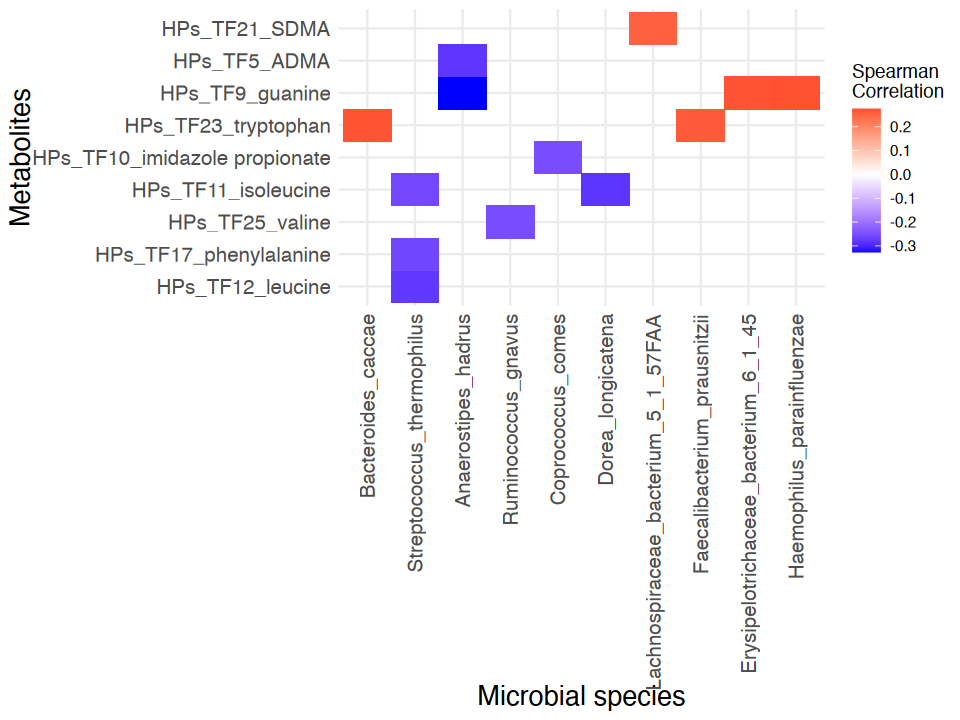

In [58]:
# Mask insignificant correlations
cor_filtered <- cor_subset
cor_filtered[p_subset >= sig_threshold] <- NA  # Set non-significant to NA

# Melt and plot
cor_melted <- melt(cor_filtered, na.rm = TRUE)

#adjust figsize
options(repr.plot.width = 8, repr.plot.height = 6)

ggplot(cor_melted, aes(x = Var2, y = Var1, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white",
                       midpoint = 0, limit = c(min(cor_melted$value, na.rm = TRUE), max(cor_melted$value, na.rm = TRUE)), space = "Lab",
                       name="Spearman\nCorrelation") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 12),
        axis.text.y = element_text(size = 12),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold")
        ) +
  labs(x = "Microbial species", y = "Metabolites", fontsize = 16)

  #print to file 
#ggsave("spearman_correlation_heatmap.png", width = 20, height = 8, dpi = 300)

In [52]:
# Schauen Sie sich die p-Werte an
summary(p_subset)
min(p_subset, na.rm = TRUE)  # Kleinster p-Wert

 Bifidobacterium_adolescentis Bifidobacterium_bifidum Bifidobacterium_longum
 Min.   :0.6401               Min.   :0.5904          Min.   :0.7738        
 1st Qu.:0.8406               1st Qu.:0.9244          1st Qu.:0.9043        
 Median :0.9092               Median :0.9563          Median :0.9432        
 Mean   :0.8731               Mean   :0.9113          Mean   :0.9175        
 3rd Qu.:0.9431               3rd Qu.:0.9703          3rd Qu.:0.9754        
 Max.   :0.9667               Max.   :0.9946          Max.   :0.9781        
 Bifidobacterium_pseudocatenulatum Collinsella_aerofaciens Eggerthella_lenta
 Min.   :0.8210                    Min.   :0.4398          Min.   :0.5789   
 1st Qu.:0.8359                    1st Qu.:0.6087          1st Qu.:0.8558   
 Median :0.8773                    Median :0.7044          Median :0.9044   
 Mean   :0.8864                    Mean   :0.7097          Mean   :0.8623   
 3rd Qu.:0.9162                    3rd Qu.:0.8394          3rd Qu.:0.9526   

[1] 0.0556477

### Question
- What are the main challenges in untargeted metabolomics compared to targeted approaches?
- Look at the example data: what can you tell about the measurement? What measurement modes or methods were used?
- Why is normalization and transformation important in metabolomics data analysis? What methods can be used?
- Which metabolite shows the strongest overall correlation with microbes?
- How would you interpret a correlation coefficient of 0.85 between a metabolite and a microbe?
- What additional metadata (e.g., diet, disease status, age, BMI, antibiotic usage) would you want to include in your analysis?
